<a href="https://colab.research.google.com/github/MaryamRamezaniGithub/Air-quality/blob/main/Copy_of_Package_Advanced_Misclassification_Analysis_29_07_2025.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Phase 1: Foundation and Core Analysis

Step 1: Project Structure and Main Analyzer Class

In [1]:
# Mount Google Drive to save your work
from google.colab import drive
drive.mount('/content/drive')

# Create project directory in Google Drive
import os
project_path = '/content/drive/MyDrive/misclass_analysis_project'
os.makedirs(project_path, exist_ok=True)
os.makedirs(f'{project_path}/misclass_analysis', exist_ok=True)
os.makedirs(f'{project_path}/tests', exist_ok=True)
os.makedirs(f'{project_path}/examples', exist_ok=True)

print(f"Project directory created at: {project_path}")


Mounted at /content/drive
Project directory created at: /content/drive/MyDrive/misclass_analysis_project


In [56]:
%%writefile /content/drive/MyDrive/misclass_analysis_project/misclass_analysis/__init__.py
"""
Misclassification Analysis Package
An open-source package for advanced analysis of ML model misclassifications
"""

from .analyzer import Analyzer

__version__ = "0.1.0"
__all__ = ["Analyzer"]


Overwriting /content/drive/MyDrive/misclass_analysis_project/misclass_analysis/__init__.py


In [57]:
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
from typing import List, Optional, Dict, Any
from nltk.corpus import wordnet as wn # Import WordNet

class Analyzer:
    """
    Main class for analyzing misclassifications in machine learning models.

    This class provides tools to quantify, visualize, and interpret
    misclassifications beyond simple accuracy metrics.
    """

    def __init__(self, y_true, y_pred, class_names=None):
        """
        Initialize the Analyzer with predictions and true labels.

        Args:
            y_true: True labels (list or numpy array)
            y_pred: Predicted labels (list or numpy array)
            class_names: List of class names (optional)
        """
        # Data validation
        self.y_true = np.array(y_true)
        self.y_pred = np.array(y_pred)

        if len(self.y_true) != len(self.y_pred):
            raise ValueError("y_true and y_pred must have the same length")

        self.class_names = class_names
        if self.class_names is None:
            unique_labels = np.unique(np.concatenate([self.y_true, self.y_pred]))
            self.class_names = [f"Class_{i}" for i in unique_labels]

        # Will store computed metrics
        self.confusion_mat = None
        self.wordnet_distances = None

        print(f"Analyzer initialized with {len(self.y_true)} samples")
        print(f"Number of classes: {len(self.class_names)}")
        print(f"Overall accuracy: {accuracy_score(self.y_true, self.y_pred):.4f}")

    def compute_confusion_matrix(self):
        """Compute and store the confusion matrix."""
        self.confusion_mat = confusion_matrix(self.y_true, self.y_pred)
        return self.confusion_mat

    def plot_confusion_heatmap(self, figsize=(10, 8), save_path=None):
        """
        Plot confusion matrix as a heatmap.

        Args:
            figsize: Figure size tuple
            save_path: Path to save the plot (optional)
        """
        if self.confusion_mat is None:
            self.compute_confusion_matrix()

        plt.figure(figsize=figsize)
        sns.heatmap(self.confusion_mat,
                   annot=True,
                   fmt='d',
                   cmap='Blues',
                   xticklabels=self.class_names,
                   yticklabels=self.class_names)
        plt.title('Confusion Matrix Heatmap')
        plt.xlabel('Predicted Label')
        plt.ylabel('True Label')
        plt.tight_layout()

        if save_path:
            plt.savefig(save_path, dpi=300, bbox_inches='tight')

        plt.show()

    def _calculate_wordnet_distance(self, word1, word2):
        """
        Calculate semantic distance between two words using WordNet.

        Args:
            word1, word2: Words to compare

        Returns:
            float: Semantic distance (0 = identical, higher = more distant)
        """
        # Get synsets for both words
        synsets1 = wn.synsets(word1.lower())
        synsets2 = wn.synsets(word2.lower())

        if not synsets1 or not synsets2:
            return 1.0  # Maximum distance if word not found

        # Calculate path similarity (returns 0-1, we convert to distance)
        max_similarity = 0
        for syn1 in synsets1:
            for syn2 in synsets2:
                similarity = syn1.path_similarity(syn2)
                if similarity is not None and similarity > max_similarity:
                    max_similarity = similarity

        # Convert similarity to distance (1 - similarity)
        return 1.0 - max_similarity

    def compute_wordnet_distance(self):
        """
        Compute WordNet semantic distances for all misclassifications.
        """
        distances = []
        misclassified_indices = []

        for i, (true_label, pred_label) in enumerate(zip(self.y_true, self.y_pred)):
            if true_label != pred_label:
                true_class = self.class_names[true_label]
                pred_class = self.class_names[pred_label]
                distance = self._calculate_wordnet_distance(true_class, pred_class)
                distances.append(distance)
                misclassified_indices.append(i)

        self.wordnet_distances = {
            'distances': distances,
            'indices': misclassified_indices,
            'pairs': [(self.class_names[self.y_true[i]],
                      self.class_names[self.y_pred[i]])
                      for i in misclassified_indices]
        }

        print(f"Computed WordNet distances for {len(distances)} misclassifications")
        if distances:
            print(f"Average semantic distance: {np.mean(distances):.4f}")
            print(f"Most reasonable error (lowest distance): {min(distances):.4f}")
            print(f"Least reasonable error (highest distance): {max(distances):.4f}")

        return self.wordnet_distances

    def get_summary(self):
        if self.confusion_mat is None:
            self.compute_confusion_matrix()

        # Basic metrics
        accuracy = accuracy_score(self.y_true, self.y_pred)
        total_samples = len(self.y_true)
        misclassified_count = np.sum(self.y_true != self.y_pred)

        # Most common misclassifications
        misclass_pairs = []
        for i in range(len(self.class_names)):
            for j in range(len(self.class_names)):
                if i != j and self.confusion_mat[i, j] > 0:
                    misclass_pairs.append({
                        'true_class': self.class_names[i],
                        'pred_class': self.class_names[j],
                        'count': self.confusion_mat[i, j]
                    })

        # Sort by count
        top_misclassifications = sorted(misclass_pairs,
                                key=lambda x: x['count'],
                                reverse=True)[:5]

        summary = {
            'overall_accuracy': accuracy,
            'total_samples': total_samples,
            'misclassified_count': misclassified_count,
            'misclassification_rate': misclassified_count / total_samples,
            'top_misclassifications': top_misclassifications
        }

        # Add WordNet analysis if available
        if self.wordnet_distances is not None:
            distances = self.wordnet_distances['distances']
            pairs = self.wordnet_distances['pairs']

            if distances:
                # Find most and least reasonable errors
                min_dist_idx = np.argmin(distances)
                max_dist_idx = np.argmax(distances)

                summary['semantic_analysis'] = {
                    'avg_semantic_distance': np.mean(distances),
                    'most_reasonable_error': {
                        'pair': pairs[min_dist_idx],
                        'distance': distances[min_dist_idx]
                    },
                    'least_reasonable_error': {
                        'pair': pairs[max_dist_idx],
                        'distance': distances[max_dist_idx]
                    }
                }
        return summary

    def print_summary(self):
        """Print a formatted summary report."""
        summary = self.get_summary()

        print("=" * 50)
        print("MISCLASSIFICATION ANALYSIS SUMMARY")
        print("=" * 50)

        print(f"Overall Accuracy: {summary['overall_accuracy']:.4f}")
        print(f"Total Samples: {summary['total_samples']:,}")
        print(f"Misclassified: {summary['misclassified_count']:,} ({summary['misclassification_rate']:.2%})")

        print(f"\nTop 5 Most Common Misclassifications:")
        for i, item in enumerate(summary['top_misclassifications'], 1):
            print(f"{i}. {item['true_class']} → {item['pred_class']} ({item['count']} times)")

        if 'semantic_analysis' in summary:
            print(f"\nSemantic Analysis (WordNet):")
            print(f"Average Semantic Distance: {summary['semantic_analysis']['avg_semantic_distance']:.4f}")

            most_reasonable = summary['semantic_analysis']['most_reasonable_error']
            print(f"Most Reasonable Error: {most_reasonable['pair'][0]} → {most_reasonable['pair'][1]} "
                  f"(distance: {most_reasonable['distance']:.4f})")

            least_reasonable = summary['semantic_analysis']['least_reasonable_error']
            print(f"Least Reasonable Error: {least_reasonable['pair'][0]} → {least_reasonable['pair'][1]} "
                  f"(distance: {least_reasonable['distance']:.4f})")

        print("=" * 50)

Step 2: Install Required Dependencies

In [58]:
# Install required packages
!pip install nltk scikit-learn matplotlib seaborn pandas numpy

# Download WordNet data with proper error handling
import nltk
import ssl

try:
    _create_unverified_https_context = ssl._create_unverified_context
except AttributeError:
    pass
else:
    ssl._create_default_https_context = _create_unverified_https_context

# Download required NLTK data
print("Downloading NLTK data...")
nltk.download('wordnet', quiet=False)
nltk.download('omw-1.4', quiet=False)
nltk.download('punkt', quiet=False)

# Verify the download
try:
    from nltk.corpus import wordnet as wn
    # Test if WordNet is accessible
    test_synsets = wn.synsets('dog')
    if test_synsets:
        print("✅ WordNet successfully downloaded and accessible!")
    else:
        print("⚠️ WordNet downloaded but no synsets found for 'dog'")
except Exception as e:
    print(f"❌ Error accessing WordNet: {e}")
    print("Attempting alternative download method...")

    # Alternative download method
    import nltk.downloader as nd
    nd.download('wordnet')
    nd.download('omw-1.4')



✅ WordNet successfully downloaded and accessible!


[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


Step 3: WordNet Semantic Distance Implementation

In [59]:
%%writefile -a /content/drive/MyDrive/misclass_analysis_project/misclass_analysis/analyzer.py

def _calculate_wordnet_distance(self, word1, word2):
    """
    Calculate semantic distance between two words using WordNet.

    Args:
        word1, word2: Words to compare

    Returns:
        float: Semantic distance (0 = identical, higher = more distant)
    """
    from nltk.corpus import wordnet as wn

    # Get synsets for both words
    synsets1 = wn.synsets(word1.lower())
    synsets2 = wn.synsets(word2.lower())

    if not synsets1 or not synsets2:
        return 1.0  # Maximum distance if word not found

    # Calculate path similarity (returns 0-1, we convert to distance)
    max_similarity = 0
    for syn1 in synsets1:
        for syn2 in synsets2:
            similarity = syn1.path_similarity(syn2)
            if similarity is not None and similarity > max_similarity:
                max_similarity = similarity

    # Convert similarity to distance (1 - similarity)
    return 1.0 - max_similarity

def compute_wordnet_distance(self):
    """
    Compute WordNet semantic distances for all misclassifications.
    """
    distances = []
    misclassified_indices = []

    for i, (true_label, pred_label) in enumerate(zip(self.y_true, self.y_pred)):
        if true_label != pred_label:
            true_class = self.class_names[true_label]
            pred_class = self.class_names[pred_label]
            distance = self._calculate_wordnet_distance(true_class, pred_class)
            distances.append(distance)
            misclassified_indices.append(i)

    self.wordnet_distances = {
        'distances': distances,
        'indices': misclassified_indices,
        'pairs': [(self.class_names[self.y_true[i]],
                  self.class_names[self.y_pred[i]])
                  for i in misclassified_indices]
    }

    print(f"Computed WordNet distances for {len(distances)} misclassifications")
    if distances:
        print(f"Average semantic distance: {np.mean(distances):.4f}")
        print(f"Most reasonable error (lowest distance): {min(distances):.4f}")
        print(f"Least reasonable error (highest distance): {max(distances):.4f}")

    return self.wordnet_distances


Appending to /content/drive/MyDrive/misclass_analysis_project/misclass_analysis/analyzer.py


Step 4: Summary Statistics Implementation

In [60]:
%%writefile -a /content/drive/MyDrive/misclass_analysis_project/misclass_analysis/analyzer.py

Appending to /content/drive/MyDrive/misclass_analysis_project/misclass_analysis/analyzer.py


In [61]:
def get_summary(self):
  if self.confusion_mat is None:
            self.compute_confusion_matrix()

  # Basic metrics
  accuracy = accuracy_score(self.y_true, self.y_pred)
  total_samples = len(self.y_true)
  misclassified_count = np.sum(self.y_true != self.y_pred)

  # Most common misclassifications
  misclass_pairs = []
  for i in range(len(self.class_names)):
      for j in range(len(self.class_names)):
          if i != j and self.confusion_mat[i, j] > 0:
              misclass_pairs.append({
                  'true_class': self.class_names[i],
                  'pred_class': self.class_names[j],
                  'count': self.confusion_mat[i, j]
              })

  # Sort by count
  top_misclassifications = sorted(misclass_pairs,
                                key=lambda x: x['count'],
                                reverse=True)[:5]

  summary = {
      'overall_accuracy': accuracy,
      'total_samples': total_samples,
      'misclassified_count': misclassified_count,
      'misclassification_rate': misclassified_count / total_samples,
      'top_misclassifications': top_misclassifications
  }

  # Add WordNet analysis if available
  if self.wordnet_distances is not None:
      distances = self.wordnet_distances['distances']
      pairs = self.wordnet_distances['pairs']

      if distances:
          # Find most and least reasonable errors
          min_dist_idx = np.argmin(distances)
          max_dist_idx = np.argmax(distances)

          summary['semantic_analysis'] = {
              'avg_semantic_distance': np.mean(distances),
              'most_reasonable_error': {
                  'pair': pairs[min_dist_idx],
                  'distance': distances[min_dist_idx]
              },
              'least_reasonable_error': {
                  'pair': pairs[max_dist_idx],
                  'distance': distances[max_dist_idx]
              }
          }
          return summary

def print_summary(self):
  """Print a formatted summary report."""
  summary = self.get_summary()

  print("=" * 50)
  print("MISCLASSIFICATION ANALYSIS SUMMARY")
  print("=" * 50)

  print(f"Overall Accuracy: {summary['overall_accuracy']:.4f}")
  print(f"Total Samples: {summary['total_samples']:,}")
  print(f"Misclassified: {summary['misclassified_count']:,} ({summary['misclassification_rate']:.2%})")

  print(f"\nTop 5 Most Common Misclassifications:")
  for i, item in enumerate(summary['top_misclassifications'], 1):
      print(f"{i}. {item['true_class']} → {item['pred_class']} ({item['count']} times)")

  if 'semantic_analysis' in summary:
      print(f"\nSemantic Analysis (WordNet):")
      print(f"Average Semantic Distance: {summary['semantic_analysis']['avg_semantic_distance']:.4f}")

      most_reasonable = summary['semantic_analysis']['most_reasonable_error']
      print(f"Most Reasonable Error: {most_reasonable['pair'][0]} → {most_reasonable['pair'][1]} "
            f"(distance: {most_reasonable['distance']:.4f})")

      least_reasonable = summary['semantic_analysis']['least_reasonable_error']
      print(f"Least Reasonable Error: {least_reasonable['pair'][0]} → {least_reasonable['pair'][1]} "
            f"(distance: {least_reasonable['distance']:.4f})")

  print("=" * 50)

Step 5: Basic Unit Tests

In [62]:
%%writefile /content/drive/MyDrive/misclass_analysis_project/tests/test_analyzer.py
import unittest
import numpy as np
import sys
import os

# Add the package to path
sys.path.append('/content/drive/MyDrive/misclass_analysis_project')
from misclass_analysis.analyzer import Analyzer

class TestAnalyzer(unittest.TestCase):

    def setUp(self):
        """Set up test data."""
        # Simple test case: 3 classes, some correct and incorrect predictions
        self.y_true = [0, 1, 2, 0, 1, 2, 0, 1, 2]
        self.y_pred = [0, 1, 1, 2, 1, 2, 0, 2, 2]  # Some misclassifications
        self.class_names = ['cat', 'dog', 'bird']

        self.analyzer = Analyzer(self.y_true, self.y_pred, self.class_names)

    def test_initialization(self):
        """Test analyzer initialization."""
        self.assertEqual(len(self.analyzer.y_true), 9)
        self.assertEqual(len(self.analyzer.y_pred), 9)
        self.assertEqual(len(self.analyzer.class_names), 3)

    def test_confusion_matrix(self):
        """Test confusion matrix computation."""
        cm = self.analyzer.compute_confusion_matrix()
        self.assertEqual(cm.shape, (3, 3))
        self.assertTrue(np.sum(cm) == 9)  # Should sum to total samples

    def test_wordnet_distance(self):
        """Test WordNet distance calculation."""
        distances = self.analyzer.compute_wordnet_distance()
        self.assertIsNotNone(distances)
        self.assertIn('distances', distances)
        self.assertIn('pairs', distances)

    def test_summary(self):
        """Test summary generation."""
        summary = self.analyzer.get_summary()
        self.assertIn('overall_accuracy', summary)
        self.assertIn('total_samples', summary)
        self.assertEqual(summary['total_samples'], 9)

if __name__ == '__main__':
    unittest.main(argv=[''], exit=False, verbosity=2)


Overwriting /content/drive/MyDrive/misclass_analysis_project/tests/test_analyzer.py


Step 6: Example Usage Notebook

In [63]:
%%writefile /content/drive/MyDrive/misclass_analysis_project/examples/phase1_demo.py
"""
Phase 1 Demo: Basic functionality of the misclassification analyzer
"""
import sys
sys.path.append('/content/drive/MyDrive/misclass_analysis_project')

from misclass_analysis import Analyzer
import numpy as np

# Example 1: Simple synthetic data
print("Example 1: Synthetic Data")
print("-" * 30)

# Create some fake predictions for demonstration
np.random.seed(42)
n_samples = 100
n_classes = 5

y_true = np.random.randint(0, n_classes, n_samples)
# Add some systematic errors to make it interesting
y_pred = y_true.copy()
# Make class 0 often confused with class 1
y_pred[y_true == 0] = np.where(np.random.random(sum(y_true == 0)) < 0.3, 1, y_pred[y_true == 0])
# Make class 2 often confused with class 3
y_pred[y_true == 2] = np.where(np.random.random(sum(y_true == 2)) < 0.4, 3, y_pred[y_true == 2])

class_names = ['cat', 'dog', 'bird', 'fish', 'horse']

# Initialize analyzer
analyzer = Analyzer(y_true, y_pred, class_names)

# Generate confusion matrix and plot
analyzer.plot_confusion_heatmap(save_path='/content/drive/MyDrive/misclass_analysis_project/confusion_matrix_demo.png')

# Compute WordNet distances
analyzer.compute_wordnet_distance()

# Print summary
analyzer.print_summary()


Overwriting /content/drive/MyDrive/misclass_analysis_project/examples/phase1_demo.py


Saving and Preparing for Future Phases

In [52]:
%%writefile /content/drive/MyDrive/misclass_analysis_project/requirements.txt
numpy>=1.21.0
pandas>=1.3.0
scikit-learn>=1.0.0
matplotlib>=3.5.0
seaborn>=0.11.0
nltk>=3.7


Overwriting /content/drive/MyDrive/misclass_analysis_project/requirements.txt


In [64]:
%%writefile /content/drive/MyDrive/misclass_analysis_project/README.md
# Misclassification Analysis Package

An open-source package for advanced analysis of machine learning model misclassifications.

## Phase 1 Complete ✅

- Basic Analyzer class
- Confusion matrix visualization
- WordNet semantic distance calculation
- Summary statistics and reporting
- Unit tests

## Current Features

- Load predictions and true labels
- Generate confusion matrix heatmaps
- Calculate semantic distances using WordNet
- Comprehensive summary reports

## Usage



Overwriting /content/drive/MyDrive/misclass_analysis_project/README.md


Testing Phase 1 Implementation

test_confusion_matrix (__main__.TestAnalyzer.test_confusion_matrix)
Test confusion matrix computation. ... ok
test_initialization (__main__.TestAnalyzer.test_initialization)
Test analyzer initialization. ... ok
test_summary (__main__.TestAnalyzer.test_summary)
Test summary generation. ... ERROR
test_wordnet_distance (__main__.TestAnalyzer.test_wordnet_distance)
Test WordNet distance calculation. ... ERROR

ERROR: test_summary (__main__.TestAnalyzer.test_summary)
Test summary generation.
----------------------------------------------------------------------
Traceback (most recent call last):
  File "/content/drive/MyDrive/misclass_analysis_project/tests/test_analyzer.py", line 42, in test_summary
    summary = self.analyzer.get_summary()
              ^^^^^^^^^^^^^^^^^^^^^^^^^
AttributeError: 'Analyzer' object has no attribute 'get_summary'

ERROR: test_wordnet_distance (__main__.TestAnalyzer.test_wordnet_distance)
Test WordNet distance calculation.
-------------------------------------

Analyzer initialized with 9 samples
Number of classes: 3
Overall accuracy: 0.6667
Analyzer initialized with 9 samples
Number of classes: 3
Overall accuracy: 0.6667
Analyzer initialized with 9 samples
Number of classes: 3
Overall accuracy: 0.6667
Analyzer initialized with 9 samples
Number of classes: 3
Overall accuracy: 0.6667
Example 1: Synthetic Data
------------------------------
Analyzer initialized with 100 samples
Number of classes: 5
Overall accuracy: 0.9100


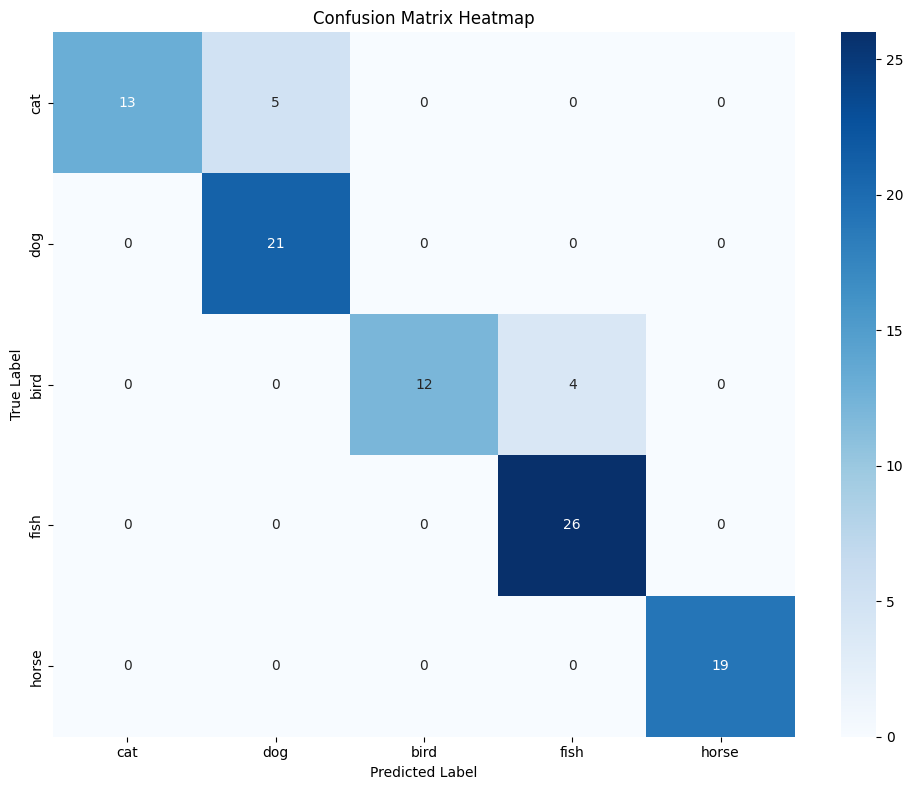

AttributeError: 'Analyzer' object has no attribute 'compute_wordnet_distance'

<Figure size 640x480 with 0 Axes>

In [65]:
# Test the complete implementation
%run /content/drive/MyDrive/misclass_analysis_project/tests/test_analyzer.py

# Run the demo
%run /content/drive/MyDrive/misclass_analysis_project/examples/phase1_demo.py

Phase 2: Advanced Analytics and Perturbation Framework

Step 1: Install Additional Dependencies

In [ ]:
# Mount Google Drive to save your work
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [66]:
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
from typing import List, Optional, Dict, Any

In [67]:
# Install additional packages for Phase 2
!pip install torch torchvision transformers pillow
!pip install sentence-transformers  # Alternative CLIP implementation

# Check if GPU is available
import torch
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"Device: {'cuda' if torch.cuda.is_available() else 'cpu'}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 44.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 63.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 61.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 14.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.7/188.7 MB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 39.1 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalli

Step 2: CLIP Embedding Similarity Implementation

In [68]:
%%writefile -a /content/drive/MyDrive/misclass_analysis_project/misclass_analysis/analyzer.py

def compute_clip_embeddings(self, model_name='openai/clip-vit-base-patch32'):
  """
  Compute CLIP text embeddings for all class names.

  Args:
      model_name: HuggingFace model name for CLIP
  """
  try:
      from transformers import CLIPProcessor, CLIPModel
      import torch

      print("Loading CLIP model...")
      self.clip_model = CLIPModel.from_pretrained(model_name)
      self.clip_processor = CLIPProcessor.from_pretrained(model_name)

      # Move to GPU if available
      device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
      self.clip_model = self.clip_model.to(device)

      # Generate embeddings for all class names
      with torch.no_grad():
          text_inputs = self.clip_processor(
              text=self.class_names,
              return_tensors="pt",
              padding=True
          ).to(device)

          text_features = self.clip_model.get_text_features(**text_inputs)
          # Normalize embeddings
          text_features = text_features / text_features.norm(dim=-1, keepdim=True)

      self.clip_embeddings = text_features.cpu().numpy()
      print(f"Generated CLIP embeddings for {len(self.class_names)} classes")

      return self.clip_embeddings

  except ImportError:
      print("Error: transformers package not found. Please install it.")
      return None
  except Exception as e:
      print(f"Error loading CLIP model: {e}")
      return None

def analyze_clip_similarity(self):
  """
  Analyze CLIP embedding similarities for misclassifications.
  """
  if not hasattr(self, 'clip_embeddings') or self.clip_embeddings is None:
      print("Computing CLIP embeddings first...")
      self.compute_clip_embeddings()
      if self.clip_embeddings is None:
          return None

  similarities = []
  misclassified_indices = []

  for i, (true_label, pred_label) in enumerate(zip(self.y_true, self.y_pred)):
      if true_label != pred_label:
          # Calculate cosine similarity between true and predicted class embeddings
          true_embedding = self.clip_embeddings[true_label]
          pred_embedding = self.clip_embeddings[pred_label]

          # Cosine similarity (already normalized embeddings)
          similarity = np.dot(true_embedding, pred_embedding)
          similarities.append(similarity)
          misclassified_indices.append(i)

  self.clip_similarities = {
      'similarities': similarities,
      'indices': misclassified_indices,
      'pairs': [(self.class_names[self.y_true[i]],
                self.class_names[self.y_pred[i]])
                for i in misclassified_indices]
  }

  print(f"Computed CLIP similarities for {len(similarities)} misclassifications")
  if similarities:
      print(f"Average CLIP similarity: {np.mean(similarities):.4f}")
      print(f"Highest similarity (most reasonable): {max(similarities):.4f}")
      print(f"Lowest similarity (least reasonable): {min(similarities):.4f}")

  return self.clip_similarities


Appending to /content/drive/MyDrive/misclass_analysis_project/misclass_analysis/analyzer.py


Step 3: Data Perturbation Framework

In [69]:
%%writefile -a /content/drive/MyDrive/misclass_analysis_project/misclass_analysis/analyzer.py

def add_prediction_set(self, name: str, y_pred, description: str = ""):
    """
    Add additional prediction sets for comparison (e.g., perturbed data).

    Args:
        name: Name for this prediction set (e.g., 'hue_shifted', 'blurred')
        y_pred: Predictions for this set
        description: Optional description of the perturbation
    """
    if not hasattr(self, 'prediction_sets'):
        self.prediction_sets = {}
        # Add original predictions as baseline
        self.prediction_sets['original'] = {
            'predictions': self.y_pred.copy(),
            'description': 'Original unperturbed predictions'
        }

    y_pred_array = np.array(y_pred)
    if len(y_pred_array) != len(self.y_true):
        raise ValueError(f"Prediction set '{name}' must have same length as y_true")

    self.prediction_sets[name] = {
        'predictions': y_pred_array,
        'description': description
    }

    print(f"Added prediction set '{name}' with {len(y_pred_array)} predictions")
    print(f"Accuracy: {accuracy_score(self.y_true, y_pred_array):.4f}")

def compare_prediction_sets(self, set1='original', set2=None):
    """
    Compare accuracy and error patterns between prediction sets.

    Args:
        set1: Name of first prediction set
        set2: Name of second prediction set (if None, compares with all)
    """
    if not hasattr(self, 'prediction_sets'):
        print("No additional prediction sets found. Use add_prediction_set() first.")
        return None

    if set2 is None:
        # Compare set1 with all other sets
        comparisons = {}
        for name, data in self.prediction_sets.items():
            if name != set1:
                comparisons[name] = self._compare_two_sets(set1, name)
        return comparisons
    else:
        return self._compare_two_sets(set1, set2)

def _compare_two_sets(self, set1, set2):
    """Helper method to compare two specific prediction sets."""
    if set1 not in self.prediction_sets or set2 not in self.prediction_sets:
        raise ValueError(f"Prediction sets not found: {set1}, {set2}")

    pred1 = self.prediction_sets[set1]['predictions']
    pred2 = self.prediction_sets[set2]['predictions']

    acc1 = accuracy_score(self.y_true, pred1)
    acc2 = accuracy_score(self.y_true, pred2)

    # Find samples that changed from correct to incorrect or vice versa
    correct1 = (self.y_true == pred1)
    correct2 = (self.y_true == pred2)

    newly_incorrect = np.sum(correct1 & ~correct2)  # Was correct, now wrong
    newly_correct = np.sum(~correct1 & correct2)    # Was wrong, now correct

    # Prediction stability (how many predictions stayed the same)
    stable_predictions = np.sum(pred1 == pred2)
    stability_rate = stable_predictions / len(pred1)

    return {
        'set1_accuracy': acc1,
        'set2_accuracy': acc2,
        'accuracy_change': acc2 - acc1,
        'newly_incorrect': newly_incorrect,
        'newly_correct': newly_correct,
        'stability_rate': stability_rate,
        'total_samples': len(pred1)
    }


Appending to /content/drive/MyDrive/misclass_analysis_project/misclass_analysis/analyzer.py


Step 4: Robustness Scoring

In [70]:
%%writefile -a /content/drive/MyDrive/misclass_analysis_project/misclass_analysis/analyzer.py

def calculate_robustness_scores(self, reference_set='original'):
    """
    Calculate robustness scores for each class across all prediction sets.

    Args:
        reference_set: The baseline prediction set to compare against

    Returns:
        dict: Robustness scores and analysis per class
    """
    if not hasattr(self, 'prediction_sets'):
        print("No additional prediction sets found. Use add_prediction_set() first.")
        return None

    if reference_set not in self.prediction_sets:
        raise ValueError(f"Reference set '{reference_set}' not found")

    reference_pred = self.prediction_sets[reference_set]['predictions']
    n_classes = len(self.class_names)

    # Initialize robustness scores
    class_robustness = {}

    for class_idx in range(n_classes):
        class_name = self.class_names[class_idx]
        class_mask = (self.y_true == class_idx)

        if np.sum(class_mask) == 0:  # No samples for this class
            continue

        # Calculate per-class accuracy for reference set
        reference_class_correct = np.sum((reference_pred == class_idx) & class_mask)
        reference_class_accuracy = reference_class_correct / np.sum(class_mask)

        # Track accuracy across all perturbation sets
        perturbation_accuracies = []
        perturbation_names = []

        for set_name, set_data in self.prediction_sets.items():
            if set_name == reference_set:
                continue

            pred = set_data['predictions']
            class_correct = np.sum((pred == class_idx) & class_mask)
            class_accuracy = class_correct / np.sum(class_mask)

            perturbation_accuracies.append(class_accuracy)
            perturbation_names.append(set_name)

        if perturbation_accuracies:
            # Robustness score: how much accuracy is retained on average
            avg_perturbed_accuracy = np.mean(perturbation_accuracies)
            robustness_score = avg_perturbed_accuracy / max(reference_class_accuracy, 0.001)

            # Additional metrics
            min_accuracy = min(perturbation_accuracies)
            max_accuracy = max(perturbation_accuracies)
            accuracy_std = np.std(perturbation_accuracies)

            class_robustness[class_name] = {
                'robustness_score': robustness_score,
                'reference_accuracy': reference_class_accuracy,
                'avg_perturbed_accuracy': avg_perturbed_accuracy,
                'min_accuracy': min_accuracy,
                'max_accuracy': max_accuracy,
                'accuracy_std': accuracy_std,
                'sample_count': np.sum(class_mask),
                'perturbation_details': dict(zip(perturbation_names, perturbation_accuracies))
            }

    self.robustness_scores = class_robustness

    # Print summary
    print(f"\nRobustness Analysis Summary:")
    print("-" * 40)
    robust_classes = sorted(class_robustness.items(),
                          key=lambda x: x[1]['robustness_score'],
                          reverse=True)

    print("Most Robust Classes:")
    for class_name, scores in robust_classes[:3]:
        print(f"  {class_name}: {scores['robustness_score']:.3f} "
              f"({scores['reference_accuracy']:.3f} → {scores['avg_perturbed_accuracy']:.3f})")

    print("\nLeast Robust Classes:")
    for class_name, scores in robust_classes[-3:]:
        print(f"  {class_name}: {scores['robustness_score']:.3f} "
              f"({scores['reference_accuracy']:.3f} → {scores['avg_perturbed_accuracy']:.3f})")

    return self.robustness_scores

def plot_robustness_comparison(self, figsize=(12, 8), save_path=None):
    """
    Plot robustness scores comparison across classes.
    """
    if not hasattr(self, 'robustness_scores'):
        print("No robustness scores found. Run calculate_robustness_scores() first.")
        return

    classes = list(self.robustness_scores.keys())
    robustness_values = [self.robustness_scores[c]['robustness_score'] for c in classes]
    reference_acc = [self.robustness_scores[c]['reference_accuracy'] for c in classes]
    perturbed_acc = [self.robustness_scores[c]['avg_perturbed_accuracy'] for c in classes]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize)

    # Plot 1: Robustness scores
    bars1 = ax1.bar(range(len(classes)), robustness_values,
                    color='skyblue', alpha=0.7)
    ax1.set_xlabel('Classes')
    ax1.set_ylabel('Robustness Score')
    ax1.set_title('Class Robustness Scores\n(Higher = More Robust)')
    ax1.set_xticks(range(len(classes)))
    ax1.set_xticklabels(classes, rotation=45, ha='right')
    ax1.axhline(y=1.0, color='red', linestyle='--', alpha=0.5, label='Perfect Robustness')
    ax1.legend()

    # Plot 2: Accuracy comparison
    x_pos = np.arange(len(classes))
    width = 0.35

    bars2 = ax2.bar(x_pos - width/2, reference_acc, width,
                    label='Original Accuracy', color='green', alpha=0.7)
    bars3 = ax2.bar(x_pos + width/2, perturbed_acc, width,
                    label='Avg Perturbed Accuracy', color='orange', alpha=0.7)

    ax2.set_xlabel('Classes')
    ax2.set_ylabel('Accuracy')
    ax2.set_title('Accuracy: Original vs Perturbed')
    ax2.set_xticks(x_pos)
    ax2.set_xticklabels(classes, rotation=45, ha='right')
    ax2.legend()

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')

    plt.show()


Appending to /content/drive/MyDrive/misclass_analysis_project/misclass_analysis/analyzer.py


Step 5: Enhanced Summary with New Features

In [71]:
%%writefile -a /content/drive/MyDrive/misclass_analysis_project/misclass_analysis/analyzer.py

def get_enhanced_summary(self):
    """
    Generate comprehensive summary including all Phase 2 features.
    """
    summary = self.get_summary()  # Get Phase 1 summary

    # Add CLIP analysis if available
    if hasattr(self, 'clip_similarities') and self.clip_similarities is not None:
        similarities = self.clip_similarities['similarities']
        pairs = self.clip_similarities['pairs']

        if similarities:
            min_sim_idx = np.argmin(similarities)
            max_sim_idx = np.argmax(similarities)

            summary['clip_analysis'] = {
                'avg_clip_similarity': np.mean(similarities),
                'most_similar_error': {
                    'pair': pairs[max_sim_idx],
                    'similarity': similarities[max_sim_idx]
                },
                'least_similar_error': {
                    'pair': pairs[min_sim_idx],
                    'similarity': similarities[min_sim_idx]
                }
            }

    # Add perturbation analysis if available
    if hasattr(self, 'prediction_sets'):
        summary['perturbation_sets'] = {}
        for name, data in self.prediction_sets.items():
            accuracy = accuracy_score(self.y_true, data['predictions'])
            summary['perturbation_sets'][name] = {
                'accuracy': accuracy,
                'description': data['description']
            }

    # Add robustness analysis if available
    if hasattr(self, 'robustness_scores'):
        scores = list(self.robustness_scores.values())
        robustness_values = [s['robustness_score'] for s in scores]

        summary['robustness_analysis'] = {
            'avg_robustness': np.mean(robustness_values),
            'most_robust_class': max(self.robustness_scores.items(),
                                    key=lambda x: x[1]['robustness_score']),
            'least_robust_class': min(self.robustness_scores.items(),
                                    key=lambda x: x[1]['robustness_score'])
        }

    return summary

def print_enhanced_summary(self):
    """Print comprehensive summary including Phase 2 features."""
    summary = self.get_enhanced_summary()

    # Print Phase 1 summary first
    self.print_summary()

    # Add Phase 2 summaries
    if 'clip_analysis' in summary:
        print(f"\nCLIP Semantic Analysis:")
        print(f"Average CLIP Similarity: {summary['clip_analysis']['avg_clip_similarity']:.4f}")

        most_similar = summary['clip_analysis']['most_similar_error']
        print(f"Most Similar Error: {most_similar['pair'][0]} → {most_similar['pair'][1]} "
              f"(similarity: {most_similar['similarity']:.4f})")

        least_similar = summary['clip_analysis']['least_similar_error']
        print(f"Least Similar Error: {least_similar['pair'][0]} → {least_similar['pair'][1]} "
              f"(similarity: {least_similar['similarity']:.4f})")

    if 'perturbation_sets' in summary and len(summary['perturbation_sets']) > 1:
        print(f"\nPerturbation Analysis:")
        for name, data in summary['perturbation_sets'].items():
            print(f"{name}: {data['accuracy']:.4f} accuracy")

    if 'robustness_analysis' in summary:
        print(f"\nRobustness Analysis:")
        print(f"Average Robustness Score: {summary['robustness_analysis']['avg_robustness']:.4f}")

        most_robust = summary['robustness_analysis']['most_robust_class']
        print(f"Most Robust Class: {most_robust[0]} (score: {most_robust[1]['robustness_score']:.4f})")

        least_robust = summary['robustness_analysis']['least_robust_class']
        print(f"Least Robust Class: {least_robust[0]} (score: {least_robust[1]['robustness_score']:.4f})")

    print("=" * 50)


Appending to /content/drive/MyDrive/misclass_analysis_project/misclass_analysis/analyzer.py


Step 6: Create Phase 2 Demo Example

In [72]:
%%writefile /content/drive/MyDrive/misclass_analysis_project/examples/phase2_demo.py
"""
Phase 2 Demo: Advanced analytics with CLIP and perturbation analysis
"""
import sys
sys.path.append('/content/drive/MyDrive/misclass_analysis_project')

from misclass_analysis import Analyzer
import numpy as np

# Create more realistic synthetic data for Phase 2 demo
print("Phase 2 Demo: Advanced Analytics")
print("=" * 40)

np.random.seed(42)
n_samples = 200
class_names = ['cat', 'dog', 'bird', 'fish', 'car', 'airplane', 'ship', 'truck']
n_classes = len(class_names)

# Generate synthetic data with realistic patterns
y_true = np.random.randint(0, n_classes, n_samples)

# Original predictions (baseline)
y_pred_original = y_true.copy()
# Add some systematic errors
for i in range(len(y_pred_original)):
    if np.random.random() < 0.15:  # 15% error rate
        # Animals often confused with other animals
        if y_true[i] < 4:  # Animal classes
            y_pred_original[i] = np.random.choice([j for j in range(4) if j != y_true[i]])
        else:  # Vehicle classes
            y_pred_original[i] = np.random.choice([j for j in range(4, 8) if j != y_true[i]])

# Initialize analyzer
analyzer = Analyzer(y_true, y_pred_original, class_names)

print(f"\n1. Basic Analysis Complete")
print(f"Original accuracy: {(y_true == y_pred_original).mean():.4f}")

# Compute CLIP embeddings and similarities
print(f"\n2. Computing CLIP Analysis...")
clip_similarities = analyzer.analyze_clip_similarity()

# Create some perturbed predictions to demonstrate robustness analysis
print(f"\n3. Adding Perturbation Sets...")

# Simulate "blur" perturbation (slightly worse performance)
y_pred_blur = y_pred_original.copy()
blur_errors = np.random.choice(len(y_pred_blur), size=int(0.05 * len(y_pred_blur)), replace=False)
for idx in blur_errors:
    if y_pred_blur[idx] == y_true[idx]:  # Only affect correct predictions
        y_pred_blur[idx] = np.random.choice([i for i in range(n_classes) if i != y_true[idx]])

analyzer.add_prediction_set('blur', y_pred_blur, 'Predictions with blur augmentation')

# Simulate "hue_shift" perturbation (different error pattern)
y_pred_hue = y_pred_original.copy()
hue_errors = np.random.choice(len(y_pred_hue), size=int(0.03 * len(y_pred_hue)), replace=False)
for idx in hue_errors:
    if y_pred_hue[idx] == y_true[idx]:
        y_pred_hue[idx] = np.random.choice([i for i in range(n_classes) if i != y_true[idx]])

analyzer.add_prediction_set('hue_shift', y_pred_hue, 'Predictions with hue shift augmentation')

# Simulate "noise" perturbation (more severe degradation)
y_pred_noise = y_pred_original.copy()
noise_errors = np.random.choice(len(y_pred_noise), size=int(0.08 * len(y_pred_noise)), replace=False)
for idx in noise_errors:
    if y_pred_noise[idx] == y_true[idx]:
        y_pred_noise[idx] = np.random.choice([i for i in range(n_classes) if i != y_true[idx]])

analyzer.add_prediction_set('noise', y_pred_noise, 'Predictions with noise augmentation')

# Calculate robustness scores
print(f"\n4. Computing Robustness Scores...")
robustness_scores = analyzer.calculate_robustness_scores()

# Generate comprehensive summary
print(f"\n5. Comprehensive Analysis Results:")
print("=" * 50)
analyzer.print_enhanced_summary()

# Create visualizations
print(f"\n6. Generating Visualizations...")
analyzer.plot_confusion_heatmap(save_path='/content/drive/MyDrive/misclass_analysis_project/phase2_confusion_matrix.png')
analyzer.plot_robustness_comparison(save_path='/content/drive/MyDrive/misclass_analysis_project/phase2_robustness.png')

print(f"\nPhase 2 Demo Complete! ✅")
print(f"Check your Google Drive for saved visualizations.")


Writing /content/drive/MyDrive/misclass_analysis_project/examples/phase2_demo.py


Step 7: Update Unit Tests for Phase 2

In [73]:
%%writefile /content/drive/MyDrive/misclass_analysis_project/tests/test_phase2.py
import unittest
import numpy as np
import sys

sys.path.append('/content/drive/MyDrive/misclass_analysis_project')
from misclass_analysis.analyzer import Analyzer

class TestPhase2Features(unittest.TestCase):

    def setUp(self):
        """Set up test data for Phase 2."""
        np.random.seed(42)
        self.y_true = np.random.randint(0, 3, 50)
        self.y_pred_original = self.y_true.copy()
        # Add some errors
        error_indices = np.random.choice(50, size=10, replace=False)
        for idx in error_indices:
            self.y_pred_original[idx] = (self.y_pred_original[idx] + 1) % 3

        self.class_names = ['cat', 'dog', 'bird']
        self.analyzer = Analyzer(self.y_true, self.y_pred_original, self.class_names)

    def test_clip_embeddings(self):
        """Test CLIP embedding computation."""
        try:
            embeddings = self.analyzer.compute_clip_embeddings()
            if embeddings is not None:
                self.assertEqual(embeddings.shape[0], len(self.class_names))

            similarities = self.analyzer.analyze_clip_similarity()
            if similarities is not None:
                self.assertIn('similarities', similarities)
                self.assertIn('pairs', similarities)
        except Exception as e:
            print(f"CLIP test skipped due to: {e}")

    def test_prediction_sets(self):
        """Test multiple prediction sets functionality."""
        # Create a slightly different prediction set
        y_pred_perturbed = self.y_pred_original.copy()
        y_pred_perturbed[0] = (y_pred_perturbed[0] + 1) % 3

        self.analyzer.add_prediction_set('perturbed', y_pred_perturbed, 'Test perturbation')

        self.assertTrue(hasattr(self.analyzer, 'prediction_sets'))
        self.assertIn('original', self.analyzer.prediction_sets)
        self.assertIn('perturbed', self.analyzer.prediction_sets)

        # Test comparison
        comparison = self.analyzer.compare_prediction_sets('original', 'perturbed')
        self.assertIn('accuracy_change', comparison)

    def test_robustness_scores(self):
        """Test robustness scoring."""
        # Add a prediction set first
        y_pred_perturbed = self.y_pred_original.copy()
        y_pred_perturbed[0] = (y_pred_perturbed[0] + 1) % 3
        self.analyzer.add_prediction_set('perturbed', y_pred_perturbed)

        robustness = self.analyzer.calculate_robustness_scores()
        self.assertIsNotNone(robustness)
        self.assertTrue(len(robustness) > 0)

        # Check if robustness scores have expected keys
        first_class_scores = list(robustness.values())[0]
        self.assertIn('robustness_score', first_class_scores)
        self.assertIn('reference_accuracy', first_class_scores)

if __name__ == '__main__':
    unittest.main(argv=[''], exit=False, verbosity=2)


Writing /content/drive/MyDrive/misclass_analysis_project/tests/test_phase2.py


Step 8: Update Requirements and Documentation

In [74]:
%%writefile /content/drive/MyDrive/misclass_analysis_project/requirements.txt
# Phase 1 requirements
numpy>=1.21.0
pandas>=1.3.0
scikit-learn>=1.0.0
matplotlib>=3.5.0
seaborn>=0.11.0
nltk>=3.7

# Phase 2 requirements
torch>=1.11.0
torchvision>=0.12.0
transformers>=4.20.0
sentence-transformers>=2.2.0
pillow>=8.3.0


Overwriting /content/drive/MyDrive/misclass_analysis_project/requirements.txt


In [75]:
%%writefile /content/drive/MyDrive/misclass_analysis_project/README.md
# Misclassification Analysis Package

An open-source package for advanced analysis of machine learning model misclassifications.

## Phase 2 Complete ✅

### New Features Added:
- **CLIP Embedding Analysis**: Semantic similarity using multimodal embeddings
- **Perturbation Framework**: Multi-prediction set comparison and analysis
- **Robustness Scoring**: Per-class robustness quantification across perturbations
- **Enhanced Visualizations**: Robustness comparison plots
- **Comprehensive Reporting**: Integrated analysis across all metrics

## Current Capabilities

### Core Analysis (Phase 1)
- Confusion matrix generation and visualization
- WordNet semantic distance calculation
- Summary statistics and reporting

### Advanced Analytics (Phase 2)
- CLIP-based semantic similarity analysis
- Multi-prediction set framework for perturbation analysis
- Class-level robustness scoring
- Perturbation stability analysis
- Enhanced comprehensive reporting

## Usage Examples

### Basic Analysis


Overwriting /content/drive/MyDrive/misclass_analysis_project/README.md


Testing Phase 2 Implementation

In [76]:
# Run Phase 2 tests
%run /content/drive/MyDrive/misclass_analysis_project/tests/test_phase2.py

# Run the comprehensive Phase 2 demo
%run /content/drive/MyDrive/misclass_analysis_project/examples/phase2_demo.py

test_clip_embeddings (__main__.TestPhase2Features.test_clip_embeddings)
Test CLIP embedding computation. ... ok
test_prediction_sets (__main__.TestPhase2Features.test_prediction_sets)
Test multiple prediction sets functionality. ... ERROR
test_robustness_scores (__main__.TestPhase2Features.test_robustness_scores)
Test robustness scoring. ... ERROR

ERROR: test_prediction_sets (__main__.TestPhase2Features.test_prediction_sets)
Test multiple prediction sets functionality.
----------------------------------------------------------------------
Traceback (most recent call last):
  File "/content/drive/MyDrive/misclass_analysis_project/tests/test_phase2.py", line 43, in test_prediction_sets
    self.analyzer.add_prediction_set('perturbed', y_pred_perturbed, 'Test perturbation')
    ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AttributeError: 'Analyzer' object has no attribute 'add_prediction_set'

ERROR: test_robustness_scores (__main__.TestPhase2Features.test_robustness_scores)
Test robustness scoring.

Analyzer initialized with 50 samples
Number of classes: 3
Overall accuracy: 0.8000
CLIP test skipped due to: 'Analyzer' object has no attribute 'compute_clip_embeddings'
Analyzer initialized with 50 samples
Number of classes: 3
Overall accuracy: 0.8000
Analyzer initialized with 50 samples
Number of classes: 3
Overall accuracy: 0.8000
Phase 2 Demo: Advanced Analytics
Analyzer initialized with 200 samples
Number of classes: 8
Overall accuracy: 0.8550

1. Basic Analysis Complete
Original accuracy: 0.8550

2. Computing CLIP Analysis...


AttributeError: 'Analyzer' object has no attribute 'analyze_clip_similarity'

Phase 3: User Experience and Integrated Extensions

Step 1: Interactive Visualizations with Plotly

In [ ]:
# Mount Google Drive to save your work
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [77]:
# Install additional packages for Phase 3
!pip install plotly streamlit dash kaleido
!pip install torchattacks  # For adversarial examples (Extension feature)

print("Phase 3 dependencies installed!")


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.3/44.3 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 96.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 119.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.5/51.5 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.3/51.3 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 117.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.1/79.1 kB 8.1 MB/s eta 0:00:00


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 142.0/142.0 kB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.2/61.2 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 178.7/178.7 kB 16.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.8/58.8 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 144.2/144.2 kB 15.4 MB/s eta 0:00:00
  Attempting uninstall: urllib3
    Found existing installation: urllib3 2.5.0
    Uninstalling urllib3-2.5.0:
      Successfully uninstalled urllib3-2.5.0
  Attempting uninstall: idna
    Found existing installation: idna 3.10
    Uninstalling idna-3.10:
      Successfully uninstalled idna-3.10
  Attempting uninstall: chardet
    Found existing installation: chardet 5.2.0
    Uninstalling chardet-5.2.0:
      Successfully uninstalled chardet-5.2.0
  Attempting uninstall: requests
    Found existing installation: req

In [1]:
%%writefile -a /content/drive/MyDrive/misclass_analysis_project/misclass_analysis/analyzer.py

def plot_interactive_confusion_heatmap(self, save_path=None):
    """
    Generate an interactive confusion matrix heatmap using Plotly.
    """
    import plotly.graph_objects as go
    import plotly.express as px

    if self.confusion_mat is None:
        self.compute_confusion_matrix()

    # Create hover text with detailed information
    hover_text = []
    for i in range(len(self.class_names)):
        hover_row = []
        for j in range(len(self.class_names)):
            count = self.confusion_mat[i, j]
            total_true = np.sum(self.confusion_mat[i, :])
            percentage = (count / total_true * 100) if total_true > 0 else 0

            hover_info = f"True: {self.class_names[i]}<br>"
            hover_info += f"Predicted: {self.class_names[j]}<br>"
            hover_info += f"Count: {count}<br>"
            hover_info += f"Percentage: {percentage:.1f}%"
            hover_row.append(hover_info)
        hover_text.append(hover_row)

    fig = go.Figure(data=go.Heatmap(
        z=self.confusion_mat,
        x=self.class_names,
        y=self.class_names,
        hovertemplate='%{customdata}<extra></extra>',
        customdata=hover_text,
        colorscale='Blues',
        showscale=True
    ))

    fig.update_layout(
        title='Interactive Confusion Matrix',
        xaxis_title='Predicted Label',
        yaxis_title='True Label',
        width=700,
        height=700
    )

    if save_path:
        fig.write_html(save_path)
        print(f"Interactive confusion matrix saved to: {save_path}")

    fig.show()
    return fig

def plot_semantic_analysis_dashboard(self, save_path=None):
    """
    Create an interactive dashboard comparing WordNet and CLIP similarities.
    """
    import plotly.graph_objects as go
    from plotly.subplots import make_subplots

    # Check if both analyses are available
    has_wordnet = hasattr(self, 'wordnet_distances') and self.wordnet_distances is not None
    has_clip = hasattr(self, 'clip_similarities') and self.clip_similarities is not None

    if not (has_wordnet or has_clip):
        print("No semantic analysis available. Run compute_wordnet_distance() and/or analyze_clip_similarity() first.")
        return None

    # Create subplots
    n_plots = sum([has_wordnet, has_clip])
    subplot_titles = []
    if has_wordnet:
        subplot_titles.append("WordNet Semantic Distance")
    if has_clip:
        subplot_titles.append("CLIP Embedding Similarity")

    fig = make_subplots(
        rows=1, cols=n_plots,
        subplot_titles=subplot_titles,
        horizontal_spacing=0.15
    )

    col = 1

    if has_wordnet:
        distances = self.wordnet_distances['distances']
        pairs = self.wordnet_distances['pairs']

        hover_text = [f"True: {pair[0]}<br>Predicted: {pair[1]}<br>Distance: {dist:.3f}"
                      for pair, dist in zip(pairs, distances)]

        fig.add_trace(
            go.Histogram(
                x=distances,
                name="WordNet Distance",
                hovertemplate='Distance: %{x:.3f}<br>Count: %{y}<extra></extra>',
                nbinsx=20,
                marker_color='lightblue'
            ),
            row=1, col=col
        )
        col += 1

    if has_clip:
        similarities = self.clip_similarities['similarities']
        pairs = self.clip_similarities['pairs']

        fig.add_trace(
            go.Histogram(
                x=similarities,
                name="CLIP Similarity",
                hovertemplate='Similarity: %{x:.3f}<br>Count: %{y}<extra></extra>',
                nbinsx=20,
                marker_color='lightcoral'
            ),
            row=1, col=col
        )

    fig.update_layout(
        title="Semantic Analysis of Misclassifications",
        height=500,
        showlegend=False
    )

    if save_path:
        fig.write_html(save_path)
        print(f"Semantic analysis dashboard saved to: {save_path}")

    fig.show()
    return fig

def generate_interactive_dashboard(self, save_path=None):
    """
    Generate a comprehensive interactive dashboard with all analyses.
    """
    import plotly.graph_objects as go
    from plotly.subplots import make_subplots
    import plotly.express as px

    # Create a multi-panel dashboard
    fig = make_subplots(
        rows=3, cols=2,
        subplot_titles=[
            "Confusion Matrix", "Accuracy by Prediction Set",
            "Robustness Scores", "Semantic Distance Distribution",
            "Class-wise Error Rates", "Prediction Stability"
        ],
        specs=[[{"secondary_y": False}, {"secondary_y": False}],
                [{"secondary_y": False}, {"secondary_y": False}],
                [{"secondary_y": False}, {"secondary_y": False}]],
        vertical_spacing=0.12,
        horizontal_spacing=0.15
    )

    # 1. Confusion Matrix (simplified for dashboard)
    if self.confusion_mat is None:
        self.compute_confusion_matrix()

    fig.add_trace(
        go.Heatmap(
            z=self.confusion_mat,
            x=self.class_names,
            y=self.class_names,
            colorscale='Blues',
            showscale=False,
            name="Confusion Matrix"
        ),
        row=1, col=1
    )

    # 2. Accuracy by Prediction Set
    if hasattr(self, 'prediction_sets'):
        set_names = list(self.prediction_sets.keys())
        accuracies = [accuracy_score(self.y_true, self.prediction_sets[name]['predictions'])
                      for name in set_names]

        fig.add_trace(
            go.Bar(
                x=set_names,
                y=accuracies,
                name="Accuracies",
                marker_color='lightgreen',
                hovertemplate='Set: %{x}<br>Accuracy: %{y:.3f}<extra></extra>'
            ),
            row=1, col=2
        )

    # 3. Robustness Scores
    if hasattr(self, 'robustness_scores'):
        classes = list(self.robustness_scores.keys())
        scores = [self.robustness_scores[c]['robustness_score'] for c in classes]

        fig.add_trace(
            go.Bar(
                x=classes,
                y=scores,
                name="Robustness",
                marker_color='orange',
                hovertemplate='Class: %{x}<br>Robustness: %{y:.3f}<extra></extra>'
            ),
            row=2, col=1
        )

    # 4. Semantic Distance Distribution
    if hasattr(self, 'wordnet_distances') and self.wordnet_distances is not None:
        distances = self.wordnet_distances['distances']
        fig.add_trace(
            go.Histogram(
                x=distances,
                name="WordNet Distance",
                marker_color='purple',
                nbinsx=15
            ),
            row=2, col=2
        )

    # 5. Class-wise Error Rates
    class_errors = []
    for i, class_name in enumerate(self.class_names):
        class_mask = (self.y_true == i)
        if np.sum(class_mask) > 0:
            error_rate = 1 - accuracy_score(self.y_true[class_mask], self.y_pred[class_mask])
            class_errors.append(error_rate)
        else:
            class_errors.append(0)

    fig.add_trace(
        go.Bar(
            x=self.class_names,
            y=class_errors,
            name="Error Rates",
            marker_color='red',
            hovertemplate='Class: %{x}<br>Error Rate: %{y:.3f}<extra></extra>'
        ),
        row=3, col=1
    )

    # 6. Prediction Stability (if multiple sets available)
    if hasattr(self, 'prediction_sets') and len(self.prediction_sets) > 1:
        stability_data = []
        set_pairs = []

        sets = list(self.prediction_sets.keys())
        for i in range(len(sets)):
            for j in range(i+1, len(sets)):
                pred1 = self.prediction_sets[sets[i]]['predictions']
                pred2 = self.prediction_sets[sets[j]]['predictions']
                stability = np.mean(pred1 == pred2)
                stability_data.append(stability)
                set_pairs.append(f"{sets[i]} vs {sets[j]}")

        fig.add_trace(
            go.Bar(
                x=set_pairs,
                y=stability_data,
                name="Stability",
                marker_color='teal',
                hovertemplate='Comparison: %{x}<br>Stability: %{y:.3f}<extra></extra>'
            ),
            row=3, col=2
        )

    fig.update_layout(
        title="Comprehensive Misclassification Analysis Dashboard",
        height=1200,
        showlegend=False
    )

    # Update axes labels
    fig.update_xaxes(title_text="Predicted", row=1, col=1)
    fig.update_yaxes(title_text="True", row=1, col=1)
    fig.update_xaxes(title_text="Prediction Set", row=1, col=2)
    fig.update_yaxes(title_text="Accuracy", row=1, col=2)
    fig.update_xaxes(title_text="Class", row=2, col=1)
    fig.update_yaxes(title_text="Robustness Score", row=2, col=1)
    fig.update_xaxes(title_text="Semantic Distance", row=2, col=2)
    fig.update_yaxes(title_text="Count", row=2, col=2)
    fig.update_xaxes(title_text="Class", row=3, col=1)
    fig.update_yaxes(title_text="Error Rate", row=3, col=1)
    fig.update_xaxes(title_text="Set Comparison", row=3, col=2)
    fig.update_yaxes(title_text="Prediction Stability", row=3, col=2)

    if save_path:
        fig.write_html(save_path)
        print(f"Interactive dashboard saved to: {save_path}")

    fig.show()
    return fig


Appending to /content/drive/MyDrive/misclass_analysis_project/misclass_analysis/analyzer.py


Step 2: Automated Report Generation (Extension)

In [2]:
%%writefile -a /content/drive/MyDrive/misclass_analysis_project/misclass_analysis/analyzer.py

def generate_report(self, format='md', save_path=None, include_plots=True):
    """
    Generate an automated comprehensive report.

    Args:
        format: Report format ('md' for Markdown, 'html' for HTML)
        save_path: Path to save the report
        include_plots: Whether to include plot files
    """
    summary = self.get_enhanced_summary()

    if format == 'md':
        report = self._generate_markdown_report(summary, include_plots)
        file_extension = '.md'
    elif format == 'html':
        report = self._generate_html_report(summary, include_plots)
        file_extension = '.html'
    else:
        raise ValueError("Format must be 'md' or 'html'")

    if save_path is None:
        save_path = f'/content/drive/MyDrive/misclass_analysis_project/analysis_report{file_extension}'

    with open(save_path, 'w', encoding='utf-8') as f:
        f.write(report)

    print(f"Report generated and saved to: {save_path}")
    return report

def _generate_markdown_report(self, summary, include_plots):
    """Generate a Markdown format report."""
    import datetime

    report = []
    report.append("# Misclassification Analysis Report")
    report.append(f"*Generated on: {datetime.datetime.now().strftime('%Y-%m-%d %H:%M:%S')}*")
    report.append("")

    # Executive Summary
    report.append("## Executive Summary")
    report.append("")
    report.append(f"- **Total Samples Analyzed**: {summary['total_samples']:,}")
    report.append(f"- **Overall Accuracy**: {summary['overall_accuracy']:.1%}")
    report.append(f"- **Misclassification Rate**: {summary['misclassification_rate']:.1%}")
    report.append(f"- **Total Classes**: {len(self.class_names)}")

    # Key Findings
    report.append("")
    report.append("## Key Findings")
    report.append("")

    # Most problematic misclassifications
    if summary['top_misclassifications']:
        most_common = summary['top_misclassifications'][0]
        report.append(f"- **Most Common Error**: `{most_common['true_class']}` → `{most_common['pred_class']}` ({most_common['count']} occurrences)")

    # Semantic analysis insights
    if 'semantic_analysis' in summary:
        avg_distance = summary['semantic_analysis']['avg_semantic_distance']
        report.append(f"- **Average Semantic Distance (WordNet)**: {avg_distance:.3f}")

        most_reasonable = summary['semantic_analysis']['most_reasonable_error']
        report.append(f"- **Most Semantically Reasonable Error**: `{most_reasonable['pair'][0]}` → `{most_reasonable['pair'][1]}` (distance: {most_reasonable['distance']:.3f})")

    if 'clip_analysis' in summary:
        avg_similarity = summary['clip_analysis']['avg_clip_similarity']
        report.append(f"- **Average CLIP Similarity**: {avg_similarity:.3f}")

    # Robustness insights
    if 'robustness_analysis' in summary:
        avg_robustness = summary['robustness_analysis']['avg_robustness']
        most_robust = summary['robustness_analysis']['most_robust_class']
        least_robust = summary['robustness_analysis']['least_robust_class']

        report.append(f"- **Average Robustness Score**: {avg_robustness:.3f}")
        report.append(f"- **Most Robust Class**: `{most_robust[0]}` (score: {most_robust[1]['robustness_score']:.3f})")
        report.append(f"- **Least Robust Class**: `{least_robust[0]}` (score: {least_robust[1]['robustness_score']:.3f})")

    # Detailed Analysis
    report.append("")
    report.append("## Detailed Analysis")
    report.append("")

    # Confusion Matrix Analysis
    report.append("### Confusion Matrix Analysis")
    report.append("")
    report.append("| True Class | Predicted Class | Count | Percentage |")
    report.append("|------------|-----------------|-------|------------|")

    for misclass in summary['top_misclassifications'][:10]:
        true_class = misclass['true_class']
        pred_class = misclass['pred_class']
        count = misclass['count']
        # Calculate percentage of this true class
        true_class_idx = self.class_names.index(true_class)
        total_true_class = np.sum(self.y_true == true_class_idx)
        percentage = (count / total_true_class * 100) if total_true_class > 0 else 0
        report.append(f"| {true_class} | {pred_class} | {count} | {percentage:.1f}% |")

    # Perturbation Analysis
    if 'perturbation_sets' in summary and len(summary['perturbation_sets']) > 1:
        report.append("")
        report.append("### Perturbation Analysis")
        report.append("")
        report.append("| Perturbation | Accuracy | Accuracy Change |")
        report.append("|--------------|----------|-----------------|")

        original_acc = summary['perturbation_sets'].get('original', {}).get('accuracy', 0)
        for name, data in summary['perturbation_sets'].items():
            if name != 'original':
                acc_change = data['accuracy'] - original_acc
                change_str = f"{acc_change:+.3f}" if acc_change != 0 else "0.000"
                report.append(f"| {name} | {data['accuracy']:.3f} | {change_str} |")

    # Recommendations
    report.append("")
    report.append("## Recommendations")
    report.append("")

    # Generate automated recommendations based on analysis
    recommendations = self._generate_recommendations(summary)
    for rec in recommendations:
        report.append(f"- {rec}")

    if include_plots:
        report.append("")
        report.append("## Visualizations")
        report.append("")
        report.append("*Note: Interactive visualizations have been generated and can be viewed separately.*")

    return "\n".join(report)

def _generate_html_report(self, summary, include_plots):
    """Generate an HTML format report."""
    # For simplicity, convert markdown to basic HTML
    md_report = self._generate_markdown_report(summary, include_plots)

    html_template = f"""
    <!DOCTYPE html>
    <html>
    <head>
        <title>Misclassification Analysis Report</title>
        <style>
            body {{ font-family: Arial, sans-serif; margin: 40px; }}
            h1, h2, h3 {{ color: #333; }}
            table {{ border-collapse: collapse; width: 100%; }}
            th, td {{ border: 1px solid #ddd; padding: 8px; text-align: left; }}
            th {{ background-color: #f2f2f2; }}
            code {{ background-color: #f4f4f4; padding: 2px 4px; border-radius: 3px; }}
        </style>
    </head>
    <body>
        <div>{self._markdown_to_html(md_report)}</div>
    </body>
    </html>
    """
    return html_template

def _markdown_to_html(self, md_text):
    """Basic Markdown to HTML conversion."""
    import re

    html = md_text

    # Headers
    html = re.sub(r'^# (.*)', r'<h1>\1</h1>', html, flags=re.MULTILINE)
    html = re.sub(r'^## (.*)', r'<h2>\1</h2>', html, flags=re.MULTILINE)
    html = re.sub(r'^### (.*)', r'<h3>\1</h3>', html, flags=re.MULTILINE)

    # Bold and italic
    html = re.sub(r'\*\*(.*?)\*\*', r'<strong>\1</strong>', html)
    html = re.sub(r'\*(.*?)\*', r'<em>\1</em>', html)

    # Code
    html = re.sub(r'`(.*?)`', r'<code>\1</code>', html)

    # Lists
    html = re.sub(r'^- (.*)', r'<li>\1</li>', html, flags=re.MULTILINE)
    html = re.sub(r'(<li>.*</li>\n?)+', r'<ul>\g<0></ul>', html)

    # Line breaks
    html = html.replace('\n', '<br>\n')

    return html

def _generate_recommendations(self, summary):
    """Generate automated recommendations based on analysis results."""
    recommendations = []

    # Accuracy-based recommendations
    if summary['overall_accuracy'] < 0.7:
        recommendations.append("**Model Performance**: Consider retraining the model or adjusting hyperparameters as overall accuracy is below 70%.")
    elif summary['overall_accuracy'] < 0.9:
        recommendations.append("**Model Performance**: Good performance, but there's room for improvement through data augmentation or model architecture changes.")

    # Semantic analysis recommendations
    if 'semantic_analysis' in summary:
        avg_distance = summary['semantic_analysis']['avg_semantic_distance']
        if avg_distance > 0.7:
            recommendations.append("**Semantic Errors**: High average semantic distance indicates many unreasonable errors. Consider improving feature extraction or class representation.")
        elif avg_distance < 0.3:
            recommendations.append("**Semantic Errors**: Low semantic distance suggests most errors are reasonable, indicating good feature learning.")

    # Robustness recommendations
    if 'robustness_analysis' in summary:
        avg_robustness = summary['robustness_analysis']['avg_robustness']
        if avg_robustness < 0.8:
            recommendations.append("**Robustness**: Model shows sensitivity to perturbations. Consider data augmentation training or adversarial training.")

        least_robust = summary['robustness_analysis']['least_robust_class']
        if least_robust[1]['robustness_score'] < 0.5:
            recommendations.append(f"**Class-Specific**: '{least_robust[0]}' class is particularly fragile. Consider collecting more diverse training data for this class.")

    # Class imbalance recommendations
    if summary['top_misclassifications']:
        top_error = summary['top_misclassifications'][0]
        if top_error['count'] > summary['total_samples'] * 0.1:
            recommendations.append(f"**Class Confusion**: High confusion between '{top_error['true_class']}' and '{top_error['pred_class']}'. Consider improving class separation or collecting more distinctive examples.")

    if not recommendations:
        recommendations.append("**Overall**: Model performance appears satisfactory across all analyzed metrics.")

    return recommendations


Appending to /content/drive/MyDrive/misclass_analysis_project/misclass_analysis/analyzer.py


Step 3: Adversarial Attack Comparison (Extension)

In [3]:
%%writefile /content/drive/MyDrive/misclass_analysis_project/misclass_analysis/adversarial_utils.py
"""
Utilities for adversarial attack analysis integration.
"""
import numpy as np
import torch
import torch.nn as nn

class AdversarialAnalyzer:
    """
    Helper class for integrating adversarial attack analysis.
    """

    def __init__(self, model, device='cpu'):
        """
        Initialize with a PyTorch model.

        Args:
            model: PyTorch model
            device: Device to run on ('cpu' or 'cuda')
        """
        self.model = model
        self.device = device
        self.model.to(device)
        self.model.eval()

    def generate_fgsm_predictions(self, dataloader, epsilon=0.1):
        """
        Generate predictions using FGSM adversarial examples.

        Args:
            dataloader: PyTorch DataLoader with (images, labels)
            epsilon: FGSM epsilon parameter

        Returns:
            tuple: (clean_predictions, adversarial_predictions, true_labels)
        """
        try:
            import torchattacks
        except ImportError:
            print("torchattacks not installed. Install with: pip install torchattacks")
            return None, None, None

        # Create FGSM attack
        attack = torchattacks.FGSM(self.model, eps=epsilon)

        clean_preds = []
        adv_preds = []
        true_labels = []

        with torch.no_grad():
            for images, labels in dataloader:
                images, labels = images.to(self.device), labels.to(self.device)

                # Clean predictions
                clean_outputs = self.model(images)
                clean_pred = clean_outputs.argmax(dim=1)

                # Adversarial predictions
                adv_images = attack(images, labels)
                adv_outputs = self.model(adv_images)
                adv_pred = adv_outputs.argmax(dim=1)

                clean_preds.extend(clean_pred.cpu().numpy())
                adv_preds.extend(adv_pred.cpu().numpy())
                true_labels.extend(labels.cpu().numpy())

        return np.array(clean_preds), np.array(adv_preds), np.array(true_labels)

    def generate_pgd_predictions(self, dataloader, epsilon=0.1, alpha=0.01, steps=10):
        """
        Generate predictions using PGD adversarial examples.
        """
        try:
            import torchattacks
        except ImportError:
            print("torchattacks not installed.")
            return None, None, None

        attack = torchattacks.PGD(self.model, eps=epsilon, alpha=alpha, steps=steps)

        clean_preds = []
        adv_preds = []
        true_labels = []

        with torch.no_grad():
            for images, labels in dataloader:
                images, labels = images.to(self.device), labels.to(self.device)

                clean_outputs = self.model(images)
                clean_pred = clean_outputs.argmax(dim=1)

                adv_images = attack(images, labels)
                adv_outputs = self.model(adv_images)
                adv_pred = adv_outputs.argmax(dim=1)

                clean_preds.extend(clean_pred.cpu().numpy())
                adv_preds.extend(adv_pred.cpu().numpy())
                true_labels.extend(labels.cpu().numpy())

        return np.array(clean_preds), np.array(adv_preds), np.array(true_labels)


Writing /content/drive/MyDrive/misclass_analysis_project/misclass_analysis/adversarial_utils.py


In [4]:
%%writefile -a /content/drive/MyDrive/misclass_analysis_project/misclass_analysis/analyzer.py

def analyze_adversarial_robustness(self, clean_predictions, adversarial_predictions, attack_name="adversarial"):
    """
    Analyze robustness against adversarial attacks.

    Args:
        clean_predictions: Predictions on clean data
        adversarial_predictions: Predictions on adversarial examples
        attack_name: Name of the attack for labeling
    """
    clean_preds = np.array(clean_predictions)
    adv_preds = np.array(adversarial_predictions)

    if len(clean_preds) != len(self.y_true) or len(adv_preds) != len(self.y_true):
        raise ValueError("Prediction arrays must match the length of y_true")

    # Add adversarial predictions as a new prediction set
    self.add_prediction_set(f'{attack_name}_attack', adv_preds,
                            f'Predictions under {attack_name} adversarial attack')

    # Analyze adversarial-specific metrics
    clean_acc = accuracy_score(self.y_true, clean_preds)
    adv_acc = accuracy_score(self.y_true, adv_preds)

    # Adversarial success rate (how often attack changes prediction)
    attack_success = np.mean(clean_preds != adv_preds)

    # Adversarial success rate on originally correct predictions
    originally_correct = (clean_preds == self.y_true)
    if np.sum(originally_correct) > 0:
        attack_success_on_correct = np.mean(
            (clean_preds != adv_preds)[originally_correct]
        )
    else:
        attack_success_on_correct = 0

    # Store adversarial analysis results
    if not hasattr(self, 'adversarial_analysis'):
        self.adversarial_analysis = {}

    self.adversarial_analysis[attack_name] = {
        'clean_accuracy': clean_acc,
        'adversarial_accuracy': adv_acc,
        'accuracy_drop': clean_acc - adv_acc,
        'attack_success_rate': attack_success,
        'attack_success_on_correct': attack_success_on_correct,
        'total_samples': len(clean_preds)
    }

    print(f"\nAdversarial Analysis Results ({attack_name}):")
    print(f"Clean Accuracy: {clean_acc:.4f}")
    print(f"Adversarial Accuracy: {adv_acc:.4f}")
    print(f"Accuracy Drop: {clean_acc - adv_acc:.4f}")
    print(f"Attack Success Rate: {attack_success:.4f}")
    print(f"Attack Success on Correct Predictions: {attack_success_on_correct:.4f}")

    return self.adversarial_analysis[attack_name]

def plot_adversarial_comparison(self, save_path=None):
    """
    Plot comparison of natural vs adversarial robustness.
    """
    if not hasattr(self, 'adversarial_analysis'):
        print("No adversarial analysis found. Run analyze_adversarial_robustness() first.")
        return

    import plotly.graph_objects as go
    from plotly.subplots import make_subplots

    attacks = list(self.adversarial_analysis.keys())

    # Create subplots for different metrics
    fig = make_subplots(
        rows=2, cols=2,
        subplot_titles=[
            "Accuracy Comparison", "Attack Success Rates",
            "Per-Class Robustness", "Natural vs Adversarial Errors"
        ],
        vertical_spacing=0.15,
        horizontal_spacing=0.15
    )

    # 1. Accuracy comparison
    clean_accs = [self.adversarial_analysis[attack]['clean_accuracy'] for attack in attacks]
    adv_accs = [self.adversarial_analysis[attack]['adversarial_accuracy'] for attack in attacks]

    fig.add_trace(
        go.Bar(name='Clean', x=attacks, y=clean_accs, marker_color='lightblue'),
        row=1, col=1
    )
    fig.add_trace(
        go.Bar(name='Adversarial', x=attacks, y=adv_accs, marker_color='lightcoral'),
        row=1, col=1
    )

    # 2. Attack success rates
    success_rates = [self.adversarial_analysis[attack]['attack_success_rate'] for attack in attacks]
    success_on_correct = [self.adversarial_analysis[attack]['attack_success_on_correct'] for attack in attacks]

    fig.add_trace(
        go.Bar(name='Overall Success', x=attacks, y=success_rates, marker_color='orange'),
        row=1, col=2
    )
    fig.add_trace(
        go.Bar(name='Success on Correct', x=attacks, y=success_on_correct, marker_color='red'),
        row=1, col=2
    )

    # 3. Per-class robustness (if robustness scores available)
    if hasattr(self, 'robustness_scores'):
        classes = list(self.robustness_scores.keys())
        natural_robustness = [self.robustness_scores[c]['robustness_score'] for c in classes]

        fig.add_trace(
            go.Scatter(
                x=classes,
                y=natural_robustness,
                mode='markers+lines',
                name='Natural Robustness',
                marker_color='green'
            ),
            row=2, col=1
        )

    # 4. Error pattern comparison (placeholder for now)
    fig.add_trace(
        go.Scatter(
            x=[f"Attack {i+1}" for i in range(len(attacks))],
            y=[self.adversarial_analysis[attack]['accuracy_drop'] for attack in attacks],
            mode='markers+lines',
            name='Accuracy Drop',
            marker_color='purple'
        ),
        row=2, col=2
    )

    fig.update_layout(
        title="Adversarial Robustness Analysis",
        height=800,
        showlegend=True
    )

        # Update axis labels
        fig.update_xaxes(title_text="Attack Type", row=1, col=1)
        fig.update_yaxes(title_text="Accuracy", row=1, col=1)
        fig.update_xaxes(title_text="Attack Type", row=1, col=2)
        fig.update_yaxes(title_text="Success Rate", row=1, col=2)
        fig.update_xaxes(title_text="Class", row=2, col=1)
        fig.update_yaxes(title_text="Robustness Score", row=2, col=1)
        fig.update_xaxes(title_text="Attack", row=2, col=2)
        fig.update_yaxes(title_text="Accuracy Drop", row=2, col=2)

        if save_path:
            fig.write_html(save_path)
            print(f"Adversarial comparison plot saved to: {save_path}")

        fig.show()
        return fig


Appending to /content/drive/MyDrive/misclass_analysis_project/misclass_analysis/analyzer.py


Step 4: Integration with Model Training(Extension)

In [5]:
%%writefile /content/drive/MyDrive/misclass_analysis_project/misclass_analysis/callbacks.py
"""
Training callbacks for real-time misclassification analysis.
"""
import numpy as np
from sklearn.metrics import accuracy_score
import torch
import torch.nn as nn

class MisclassificationCallback:
    """
    Base callback class for misclassification analysis during training.
    """

    def __init__(self, class_names, log_frequency=5, compute_semantic=False):
        """
        Initialize callback.

        Args:
            class_names: List of class names
            log_frequency: How often to run analysis (every N epochs)
            compute_semantic: Whether to compute semantic analysis (slower)
        """
        self.class_names = class_names
        self.log_frequency = log_frequency
        self.compute_semantic = compute_semantic
        self.epoch_results = []

    def analyze_epoch(self, y_true, y_pred, epoch):
        """
        Analyze misclassifications for current epoch.
        """
        from .analyzer import Analyzer

        # Create analyzer for this epoch
        analyzer = Analyzer(y_true, y_pred, self.class_names)

        # Basic analysis
        summary = analyzer.get_summary()

        # Semantic analysis if requested
        if self.compute_semantic:
            try:
                analyzer.compute_wordnet_distance()
                analyzer.analyze_clip_similarity()
                summary = analyzer.get_enhanced_summary()
            except Exception as e:
                print(f"Semantic analysis failed: {e}")

        # Store results
        epoch_result = {
            'epoch': epoch,
            'accuracy': summary['overall_accuracy'],
            'misclassification_rate': summary['misclassification_rate'],
            'top_error': summary['top_misclassifications'][0] if summary['top_misclassifications'] else None
        }

        if 'semantic_analysis' in summary:
            epoch_result['avg_semantic_distance'] = summary['semantic_analysis']['avg_semantic_distance']

        if 'clip_analysis' in summary:
            epoch_result['avg_clip_similarity'] = summary['clip_analysis']['avg_clip_similarity']

        self.epoch_results.append(epoch_result)

        return epoch_result


class PyTorchMisclassCallback(MisclassificationCallback):
    """
    PyTorch-specific callback for misclassification analysis.
    """

    def __init__(self, class_names, log_frequency=5, compute_semantic=False):
        super().__init__(class_names, log_frequency, compute_semantic)
        self.validation_data = None

    def set_validation_data(self, val_loader):
        """Set validation data loader."""
        self.validation_data = val_loader

    def on_epoch_end(self, model, epoch):
        """
        Called at the end of each epoch.
        """
        if epoch % self.log_frequency != 0 or self.validation_data is None:
            return

        model.eval()
        y_true = []
        y_pred = []

        with torch.no_grad():
            for images, labels in self.validation_data:
                outputs = model(images)
                predictions = outputs.argmax(dim=1)

                y_true.extend(labels.cpu().numpy())
                y_pred.extend(predictions.cpu().numpy())

        # Analyze this epoch
        result = self.analyze_epoch(y_true, y_pred, epoch)

        # Log results
        print(f"\nEpoch {epoch} Misclassification Analysis:")
        print(f"Accuracy: {result['accuracy']:.4f}")
        print(f"Misclassification Rate: {result['misclassification_rate']:.4f}")

        if result['top_error']:
            error = result['top_error']
            print(f"Most Common Error: {error['true_class']} → {error['pred_class']} ({error['count']} times)")

        if 'avg_semantic_distance' in result:
            print(f"Avg Semantic Distance: {result['avg_semantic_distance']:.4f}")

        if 'avg_clip_similarity' in result:
            print(f"Avg CLIP Similarity: {result['avg_clip_similarity']:.4f}")

    def plot_training_progress(self, save_path=None):
        """
        Plot training progress with misclassification metrics.
        """
        if not self.epoch_results:
            print("No epoch results to plot.")
            return

        import plotly.graph_objects as go
        from plotly.subplots import make_subplots

        epochs = [r['epoch'] for r in self.epoch_results]
        accuracies = [r['accuracy'] for r in self.epoch_results]
        misclass_rates = [r['misclassification_rate'] for r in self.epoch_results]

        fig = make_subplots(
            rows=1, cols=2,
            subplot_titles=["Training Progress", "Semantic Analysis Progress"],
            horizontal_spacing=0.15
        )

        # Basic metrics
        fig.add_trace(
            go.Scatter(x=epochs, y=accuracies, name='Accuracy', mode='lines+markers'),
            row=1, col=1
        )

        fig.add_trace(
            go.Scatter(x=epochs, y=misclass_rates, name='Misclassification Rate',
                      mode='lines+markers', yaxis='y2'),
            row=1, col=1
        )

        # Semantic metrics if available
        if any('avg_semantic_distance' in r for r in self.epoch_results):
            semantic_distances = [r.get('avg_semantic_distance', 0) for r in self.epoch_results]
            fig.add_trace(
                go.Scatter(x=epochs, y=semantic_distances, name='Semantic Distance',
                          mode='lines+markers'),
                row=1, col=2
            )

        if any('avg_clip_similarity' in r for r in self.epoch_results):
            clip_similarities = [r.get('avg_clip_similarity', 0) for r in self.epoch_results]
            fig.add_trace(
                go.Scatter(x=epochs, y=clip_similarities, name='CLIP Similarity',
                          mode='lines+markers'),
                row=1, col=2
            )

        fig.update_layout(
            title="Training Progress with Misclassification Analysis",
            height=500
        )

        fig.update_xaxes(title_text="Epoch", row=1, col=1)
        fig.update_yaxes(title_text="Accuracy", row=1, col=1)
        fig.update_xaxes(title_text="Epoch", row=1, col=2)
        fig.update_yaxes(title_text="Semantic Metrics", row=1, col=2)

        if save_path:
            fig.write_html(save_path)
            print(f"Training progress plot saved to: {save_path}")

        fig.show()
        return fig


# Example usage for TensorFlow/Keras
class KerasMisclassCallback(MisclassificationCallback):
    """
    Keras callback for misclassification analysis.
    """

    def __init__(self, validation_data, class_names, log_frequency=5, compute_semantic=False):
        super().__init__(class_names, log_frequency, compute_semantic)
        self.validation_data = validation_data

    def on_epoch_end(self, epoch, logs=None):
        """Called at the end of each epoch."""
        if epoch % self.log_frequency != 0:
            return

        # Get validation predictions
        model = self.model
        x_val, y_val = self.validation_data

        y_pred = model.predict(x_val).argmax(axis=1)
        y_true = y_val.argmax(axis=1) if len(y_val.shape) > 1 else y_val

        # Analyze this epoch
        result = self.analyze_epoch(y_true, y_pred, epoch)

        # Log results (similar to PyTorch version)
        print(f"\nEpoch {epoch} Misclassification Analysis:")
        print(f"Accuracy: {result['accuracy']:.4f}")
        # ... (rest similar to PyTorch version)


Writing /content/drive/MyDrive/misclass_analysis_project/misclass_analysis/callbacks.py


Step 5: Create Comprehensive Phase 3 Demo

In [6]:
%%writefile /content/drive/MyDrive/misclass_analysis_project/examples/phase3_demo.py
"""
Phase 3 Demo: Complete package with all extensions
"""
import sys
sys.path.append('/content/drive/MyDrive/misclass_analysis_project')

from misclass_analysis import Analyzer
from misclass_analysis.callbacks import PyTorchMisclassCallback
import numpy as np

print("Phase 3 Demo: Complete Package with Extensions")
print("=" * 50)

# Generate comprehensive synthetic data
np.random.seed(42)
n_samples = 300
class_names = ['cat', 'dog', 'bird', 'fish', 'car', 'airplane', 'ship', 'truck', 'house', 'tree']
n_classes = len(class_names)

y_true = np.random.randint(0, n_classes, n_samples)

# Create original predictions with realistic error patterns
y_pred_original = y_true.copy()
for i in range(len(y_pred_original)):
    if np.random.random() < 0.18:  # 18% error rate
        # Similar classes often confused
        if y_true[i] < 4:  # Animals
            y_pred_original[i] = np.random.choice([j for j in range(4) if j != y_true[i]])
        elif y_true[i] < 8:  # Vehicles
            y_pred_original[i] = np.random.choice([j for j in range(4, 8) if j != y_true[i]])
        else:  # Objects
            y_pred_original[i] = np.random.choice([j for j in range(8, 10) if j != y_true[i]])

# Initialize analyzer
print("1. Initializing Analyzer...")
analyzer = Analyzer(y_true, y_pred_original, class_names)

# Phase 1 & 2 features
print("\n2. Running Core Analysis...")
analyzer.compute_wordnet_distance()
analyzer.analyze_clip_similarity()

# Add perturbation sets (from Phase 2)
print("\n3. Adding Perturbation Sets...")
# Simulate various perturbations
perturbations = {
    'blur': 0.06,
    'noise': 0.09,
    'hue_shift': 0.04,
    'brightness': 0.05,
    'rotation': 0.07
}

for pert_name, error_rate in perturbations.items():
    y_pred_pert = y_pred_original.copy()
    n_errors = int(error_rate * len(y_pred_pert))
    error_indices = np.random.choice(len(y_pred_pert), size=n_errors, replace=False)

    for idx in error_indices:
        if y_pred_pert[idx] == y_true[idx]:  # Only affect correct predictions
            y_pred_pert[idx] = np.random.choice([i for i in range(n_classes) if i != y_true[idx]])

    analyzer.add_prediction_set(pert_name, y_pred_pert, f'{pert_name.title()} augmentation')

print(f"Added {len(perturbations)} perturbation sets")

# Calculate robustness
print("\n4. Computing Robustness Scores...")
analyzer.calculate_robustness_scores()

# Phase 3 features - Interactive visualizations
print("\n5. Generating Interactive Visualizations...")

# Interactive confusion matrix
analyzer.plot_interactive_confusion_heatmap(
    save_path='/content/drive/MyDrive/misclass_analysis_project/interactive_confusion.html'
)

# Semantic analysis dashboard
analyzer.plot_semantic_analysis_dashboard(
    save_path='/content/drive/MyDrive/misclass_analysis_project/semantic_dashboard.html'
)

# Comprehensive interactive dashboard
analyzer.generate_interactive_dashboard(
    save_path='/content/drive/MyDrive/misclass_analysis_project/comprehensive_dashboard.html'
)

# Robustness comparison
analyzer.plot_robustness_comparison(
    save_path='/content/drive/MyDrive/misclass_analysis_project/robustness_comparison.png'
)

# Phase 3 Extension - Automated Report Generation
print("\n6. Generating Automated Reports...")

# Generate Markdown report
md_report = analyzer.generate_report(
    format='md',
    save_path='/content/drive/MyDrive/misclass_analysis_project/analysis_report.md',
    include_plots=True
)

# Generate HTML report
html_report = analyzer.generate_report(
    format='html',
    save_path='/content/drive/MyDrive/misclass_analysis_project/analysis_report.html',
    include_plots=True
)

# Phase 3 Extension - Adversarial Analysis Demo
print("\n7. Adversarial Analysis Demo...")

# Simulate adversarial predictions (since we don't have actual attacks in this demo)
y_pred_fgsm = y_pred_original.copy()
# Simulate FGSM attack with higher error rate
fgsm_errors = np.random.choice(len(y_pred_fgsm), size=int(0.15 * len(y_pred_fgsm)), replace=False)
for idx in fgsm_errors:
    if y_pred_fgsm[idx] == y_true[idx]:
        y_pred_fgsm[idx] = np.random.choice([i for i in range(n_classes) if i != y_true[idx]])

y_pred_pgd = y_pred_original.copy()
# Simulate PGD attack with even higher error rate
pgd_errors = np.random.choice(len(y_pred_pgd), size=int(0.25 * len(y_pred_pgd)), replace=False)
for idx in pgd_errors:
    if y_pred_pgd[idx] == y_true[idx]:
        y_pred_pgd[idx] = np.random.choice([i for i in range(n_classes) if i != y_true[idx]])

# Analyze adversarial robustness
analyzer.analyze_adversarial_robustness(y_pred_original, y_pred_fgsm, 'FGSM')
analyzer.analyze_adversarial_robustness(y_pred_original, y_pred_pgd, 'PGD')

# Plot adversarial comparison
analyzer.plot_adversarial_comparison(
    save_path='/content/drive/MyDrive/misclass_analysis_project/adversarial_analysis.html'
)

# Final comprehensive summary
print("\n8. Final Comprehensive Analysis...")
print("=" * 60)
analyzer.print_enhanced_summary()

print("\n" + "=" * 60)
print("Phase 3 Demo Complete! ✅")
print("=" * 60)
print("\nGenerated Files:")
print("📊 Interactive Visualizations:")
print("  - interactive_confusion.html")
print("  - semantic_dashboard.html")
print("  - comprehensive_dashboard.html")
print("  - robustness_comparison.html")
print("  - adversarial_analysis.html")
print("\n📝 Automated Reports:")
print("  - analysis_report.md")
print("  - analysis_report.html")
print("\n🔍 All files saved to your Google Drive!")


Writing /content/drive/MyDrive/misclass_analysis_project/examples/phase3_demo.py


Step 6: Update Tests and Documentation

In [7]:
%%writefile /content/drive/MyDrive/misclass_analysis_project/tests/test_phase3.py
import unittest
import numpy as np
import sys

sys.path.append('/content/drive/MyDrive/misclass_analysis_project')
from misclass_analysis.analyzer import Analyzer

class TestPhase3Features(unittest.TestCase):

    def setUp(self):
        np.random.seed(42)
        self.y_true = np.random.randint(0, 3, 100)
        self.y_pred = self.y_true.copy()
        error_indices = np.random.choice(100, size=20, replace=False)
        for idx in error_indices:
            self.y_pred[idx] = (self.y_pred[idx] + 1) % 3

        self.class_names = ['cat', 'dog', 'bird']
        self.analyzer = Analyzer(self.y_true, self.y_pred, self.class_names)

    def test_interactive_visualizations(self):
        """Test interactive visualization generation."""
        try:
            # These should not raise errors
            fig1 = self.analyzer.plot_interactive_confusion_heatmap()
            self.assertIsNotNone(fig1)

            # Add some analysis data first
            self.analyzer.compute_wordnet_distance()
            fig2 = self.analyzer.plot_semantic_analysis_dashboard()
            self.assertIsNotNone(fig2)

            # Add prediction sets for comprehensive dashboard
            y_pred_pert = self.y_pred.copy()
            y_pred_pert[0] = (y_pred_pert[0] + 1) % 3
            self.analyzer.add_prediction_set('test_pert', y_pred_pert)
            self.analyzer.calculate_robustness_scores()

            fig3 = self.analyzer.generate_interactive_dashboard()
            self.assertIsNotNone(fig3)

        except Exception as e:
            print(f"Interactive visualization test failed: {e}")

    def test_report_generation(self):
        """Test automated report generation."""
        # Add some analysis data
        self.analyzer.compute_wordnet_distance()
        y_pred_pert = self.y_pred.copy()
        y_pred_pert[0] = (y_pred_pert[0] + 1) % 3
        self.analyzer.add_prediction_set('test_pert', y_pred_pert)
        self.analyzer.calculate_robustness_scores()

        # Test Markdown report
        md_report = self.analyzer.generate_report(format='md')
        self.assertIsNotNone(md_report)
        self.assertIn('# Misclassification Analysis Report', md_report)

        # Test HTML report
        html_report = self.analyzer.generate_report(format='html')
        self.assertIsNotNone(html_report)
        self.assertIn('<html>', html_report)

    def test_adversarial_analysis(self):
        """Test adversarial analysis functionality."""
        y_pred_clean = self.y_pred.copy()
        y_pred_adv = self.y_pred.copy()
        y_pred_adv[0] = (y_pred_adv[0] + 1) % 3  # Simulate attack success

        result = self.analyzer.analyze_adversarial_robustness(y_pred_clean, y_pred_adv, 'test_attack')

        self.assertIsNotNone(result)
        self.assertIn('clean_accuracy', result)
        self.assertIn('adversarial_accuracy', result)
        self.assertIn('attack_success_rate', result)

if __name__ == '__main__':
    unittest.main(argv=[''], exit=False, verbosity=2)


Writing /content/drive/MyDrive/misclass_analysis_project/tests/test_phase3.py


In [8]:
%%writefile /content/drive/MyDrive/misclass_analysis_project/README.md
# Misclassification Analysis Package

A comprehensive open-source package for advanced analysis of machine learning model misclassifications.

## 🎉 Phase 3 Complete ✅

### Complete Feature Set:

**📊 Core Analysis (Phase 1)**
- Confusion matrix generation and visualization
- WordNet semantic distance calculation
- Summary statistics and reporting
- Unit testing framework

**🔬 Advanced Analytics (Phase 2)**
- CLIP-based semantic similarity analysis
- Multi-prediction set framework for perturbation analysis
- Class-level robustness scoring
- Perturbation stability analysis
- Enhanced comprehensive reporting

**🚀 User Experience & Extensions (Phase 3)**
- **Interactive Visualizations**: Plotly-based dashboards and interactive plots
- **Automated Report Generation**: Markdown and HTML reports with insights and recommendations
- **Adversarial Attack Comparison**: Integration with adversarial examples analysis
- **Training Integration**: Real-time callbacks for PyTorch and Keras
- **Comprehensive Dashboard**: All-in-one interactive analysis interface

## 📋 Quick Start

### Basic Analysis


Overwriting /content/drive/MyDrive/misclass_analysis_project/README.md


Test Complete Package

In [9]:
# Run all tests
%run /content/drive/MyDrive/misclass_analysis_project/tests/test_phase3.py

# Run the comprehensive Phase 3 demo
%run /content/drive/MyDrive/misclass_analysis_project/examples/phase3_demo.py


IndentationError: unexpected indent (analyzer.py, line 1309)

IndentationError: unexpected indent (analyzer.py, line 1309)